In [46]:
from dappy import read
from dappy import vis
import numpy as np
import time
# from IPython.display import Video
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

import scipy.stats as stats
import scipy.spatial.distance as distances

from dappy import preprocess
from dappy import write
from dappy import features
from dappy import analysis

import pandas as pd
import copy
import os
import pickle
%matplotlib inline



In [64]:
from numba import njit, prange
import dask

In [47]:
# Set Plotting params
def reset_rcparams():
    matplotlib.rcdefaults()
    matplotlib.rcParams['font.family'] = "Arial"
    plt.rcParams['xtick.direction'] = 'out'
    plt.rcParams['ytick.direction'] = 'out'
    plt.rcParams['axes.linewidth'] = 0.8
    plt.rcParams['lines.linewidth'] = 0.8
    plt.rcParams['axes.labelpad'] = 2

    major = 2
    majorpad = 2
    plt.rcParams['xtick.major.size'] = major
    plt.rcParams['ytick.major.size'] = major
    plt.rcParams['xtick.major.width'] = 0.4
    plt.rcParams['ytick.major.width'] = 0.4
    plt.rcParams['xtick.major.pad'] = majorpad
    plt.rcParams['ytick.major.pad'] = majorpad
    plt.rcParams['xtick.labelsize'] = 5
    plt.rcParams['ytick.labelsize'] = 5
    plt.rcParams['axes.labelsize'] = 5

    plt.rcParams["legend.borderpad"] = 0
    plt.rcParams["legend.framealpha"] = 0
    plt.rcParams["legend.fontsize"] = 5

def hide_axes_top_right(ax):
    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)

def hide_axes_all(ax):
    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)
    ax.spines.left.set_visible(False)
    ax.spines.bottom.set_visible(False)

# every dimension is in millimeter
mm = 1/25.4

In [48]:
# analysis_key = "SU_trial"
# analysis_key = "cross_test_align"
analysis_key = "cross_test"
# analysis_key = "FaceDannce"
config = read.config("/hpc/group/tdunn/Bryan_Rigs/SmallOpenField/dappy/configs/" + analysis_key + ".yaml")
do_diff_ds = False
drop_tail = True
drop_shoulders = False #True
tail_kps = [6,7]

connectivity = read.connectivity(
    path=config["skeleton_path"], skeleton_name=config["skeleton_name"]
)

# # Make out_path
# Path(config["out_path"]).mkdir(parents=True, exist_ok=True)

# # Merge prediction
# pose, ids, meta, meta_by_frame = read.pose_from_meta(
#     path=config["meta_path"], connectivity=connectivity
# )

In [49]:
def get_freq_df(config, file_name, idx_ax_name='Clusters', col_ax_name='id'):
    cf = pd.read_csv(''.join([config['out_path'],f'/{file_name}']), index_col=0)
    
    # if columns have non-string name, change them to int
    try:
        cf.columns = cf.columns.values.astype(int)
    except ValueError as ve1:
        if 'invalid literal for int() with base 10:' in str(ve1):
            cf.columns = cf.columns.values.astype(float).astype(int)
    
    cf = cf.rename_axis(idx_ax_name, axis="index")
    cf = cf.rename_axis(col_ax_name, axis="columns")

    return cf

In [50]:
from postanalysis.analysis_utils import map_to_group
def get_data_obj(
    config,
    file_name,
    col_renames = None,
    group_id_col = 'Timepoint',
    ):
    with open(''.join([config['out_path'], f"/{file_name}"]), "rb") as dobj:
        data_obj = pickle.load(dobj)
    
    df = data_obj.data
    mf = data_obj.meta
    mff = data_obj.meta_by_frame

    dfs_to_map = [df, mf, mff]
    if col_renames is not None:
        # col_rename = {"Condition": "ConditionName", "Timepoint": "Condition"}
        col_rename = col_renames

        for idx,df_ in enumerate(dfs_to_map):
            print(idx)
            map_to_group(df_, column_name=group_id_col, do_col_rename=col_rename)
            df_ = df_.rename(columns=col_rename, inplace=True)
    
    return df, mf, mff



In [51]:
freq_df = get_freq_df(config,'cluster_occupancy.csv')

In [52]:
df,mf,mff = get_data_obj(config, 'datastruct.p', col_renames={"Condition": "ConditionName", "Timepoint": "Condition"})

0
1
2


/hpc/group/tdunn/Bryan_Rigs/SmallOpenField/dappy/src/postanalysis/analysis_utils.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inpdf[column_name] = pd.Categorical(inpdf[column_name].astype(str))
/hpc/group/tdunn/Bryan_Rigs/SmallOpenField/dappy/src/postanalysis/analysis_utils.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inpdf['GroupID'] = inpdf[column_name].cat.codes + 1
/tmp/ipykernel_2248921/3354408969.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

### Consolidate all the processing beforehand

In [53]:
def get_pivot_table(mf, freq_df, 
                    relevant_columns_frm_meta = ['Condition', 'GroupID', 'AnimalID', 'id'],
                    piv_col = 'Clusters', 
                    piv_vals = 'occupancy',
                    index_level = [ 'Condition',
                                    'Clusters', 
                                    'GroupID', 
                                    'id', 
                                    'AnimalID'],
                    ):

    group = mf.loc[:,relevant_columns_frm_meta]
    occu_by_group = pd.merge(freq_df.stack().to_frame(piv_vals).reset_index(), group, on='id', 
                                validate='many_to_one')
    pivot_idx = [col for col in index_level if col not in [piv_col, piv_vals] ]
    as_og = occu_by_group.set_index(index_level).sort_index(level=index_level)
    as_og_pivot = as_og.reset_index().pivot(index=pivot_idx, columns=piv_col, values=piv_vals)

    return as_og_pivot, pivot_idx

In [54]:
t,idxs = get_pivot_table(mf, freq_df=freq_df)

In [55]:
unqs = t.index.get_level_values('Condition').astype(str).unique()
for i in unqs:
    for j in unqs:
        print(i,j)

Demo Demo
Demo Habituation
Habituation Demo
Habituation Habituation


## Permutation Testing/ Bootstrap Testing

Lets say there are 2 groups, and 
1. We label the mouse randomly
2. Take the difference between the centroids of the 2 groups as test-statistic
3. Plot the test statistic distribution, and check the p-value for the position of actual statistic 

| Condition | GroupID | AnimalID | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|---|---|
| baseline | 1686940_both | 0 | 0.00 | 0.00 | 0.000139 | 0.006556 | 0.000000 |
| baseline | 1686940_left | 0 | 0.00 | 0.00 | 0.000000 | 0.008056 | 0.000000 |
| habituation | 21686940_both | 0 | 0.00 | 0.000306 | 0.002250 | 0.000000 | 0.000000 |
| habituation | 21686940_none | 0 | 0.00 | 0.000000 | 0.000000 | 0.000000 | 0.000000 |

In [56]:
def centroid_distance(arr_1, arr_2, axis=0, distance_metric=distances.euclidean):
    # print(f"Shape of arr1 = {arr_1.shape}, Shape of arr2 = {arr_2.shape}")
    cent_1 = arr_1.mean(axis=axis)
    cent_2 = arr_2.mean(axis=axis)

    # print(f"Shape of cent1 = {cent_1.shape}, Shape of cent2 = {cent_2.shape}")
    # if len(cent_1.shape) > 1:
    # return distances.cdist(cent_1, cent_2)
    # else:
    return distances.euclidean(cent_1, cent_2)

In [76]:
@dask.delayed
def get_shuffled_stat(occu_data, len_gp_1, len_gp_2, distance_function):

        # Do a random permutation
        rand_perm = np.random.permutation(occu_data)
        gp_1 = rand_perm[:len_gp_1]
        gp_2 = rand_perm[len_gp_1:]

        len_gp_1 = gp_1.shape[0]
        len_gp_2 = gp_2.shape[0]

        shuffled_stat = distance_function(gp_1,gp_2)

        return shuffled_stat

def do_permutation_test(pivot_df, 
                        group_names, 
                        ndraws=None, 
                        distance_function=centroid_distance,
                        **kwargs2):
    """
    Lets say there are 2 groups, and 
        1. We label the mouse randomly
        2. Take the difference between the centroids of the 2 groups as test-statistic
        3. Plot the test statistic distribution, and check the p-value for the position of actual statistic
    
    Inputs:
        pivot_df: dataframe of the form generated by above script
                | Condition | GroupID | AnimalID | 0 | 1 | 2 | 3 | 4 |
                |---|---|---|---|---|---|---|---|
                | baseline | 1686940_both | 0 | 0.00 | 0.00 | 0.000139 | 0.006556 | 0.000000 |
                | baseline | 1686940_left | 0 | 0.00 | 0.00 | 0.000000 | 0.008056 | 0.000000 |
                | habituation | 21686940_both | 0 | 0.00 | 0.000306 | 0.002250 | 0.000000 | 0.000000 |
                | habituation | 21686940_none | 0 | 0.00 | 0.000000 | 0.000000 | 0.000000 | 0.000000 |
        group_names: List of condition names
        ndraws: 
    """
    if ndraws is None:
        ndraws=10000
    
    subsample_df = pivot_df.loc[group_names].reset_index()
    gp_1 = pivot_df.loc[group_names[0]]
    gp_2 = pivot_df.loc[group_names[1]]
    len_gp_1 = gp_1.shape[0]
    len_gp_2 = gp_2.shape[0]

    assert len_gp_1+len_gp_2 == subsample_df.shape[0]

    act_stat = distance_function(gp_1.values,gp_2.values)

    cols = subsample_df.columns
    cluster_cols = [col for col in cols if isinstance(col,int)]
    occupancy_data = subsample_df[cluster_cols]
    
    test_stat_dist = np.zeros(ndraws)
    delayed_results = []
    for draw in range(ndraws):

        # Do a random permutation
        # rand_perm = np.random.permutation(occupancy_data)
        # gp_1 = rand_perm[:len_gp_1]
        # gp_2 = rand_perm[len_gp_1:]

        # len_gp_1 = gp_1.shape[0]
        # len_gp_2 = gp_2.shape[0]

        # shuffled_stat = distance_function(gp_1,gp_2)

        # test_stat_dist[draw] = shuffled_stat

        # Try dask based parallelization
        shuffled_stat = get_shuffled_stat(occupancy_data, len_gp_1, len_gp_2, distance_function)
        delayed_results.append(shuffled_stat)

    test_stat_dist = np.asarray(dask.compute(*delayed_results))
    
    count_more_extreme = np.sum(test_stat_dist >= act_stat)
    p_value = count_more_extreme / len(test_stat_dist)

    # fig, ax = plt.subplots(nrows=1, ncols=1, **kwargs2)
    # ax.hist(stat_dist)
    # ax.axvline(x=act_stat, color='red', linestyle='--')
    # fig.show()
    # print(f'p-value = {p_value}')

    return p_value, test_stat_dist, act_stat




In [77]:
test_pivot = pd.read_csv('/hpc/group/tdunn/Bryan_Rigs/SmallOpenField/dappy/results/forDUNE/fitsne_fromtry3_copy/og_pivot.csv')

In [78]:
test_pivot_ = test_pivot.set_index(['Condition', 'GroupID', 'AnimalID'])
test_pivot_

0         1    2    3         4    5  \
Condition   GroupID AnimalID                                                
Baseline    2       1686940_none   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686940_right  0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_both   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_none   0.0  0.000000  0.0  0.0  0.000000  0.0   
            3       1686940_both   0.0  0.000000  0.0  0.0  0.001833  0.0   
                    1686941_left   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_right  0.0  0.000000  0.0  0.0  0.000000  0.0   
Habituation 2       1686940_none   0.0  0.000000  0.0  0.0  0.000083  0.0   
                    1686940_right  0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_both   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_none   0.0  0.000000  0.0  0.0  0.000000  0.0   
            3       1686940_both   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_left   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_right  0.0  0.000000  0.0  0.0  0.000000  0.0   
Timepoint1  2       1686940_none   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686940_right  0.0  0.000000  0.0  0.0  0.000056  0.0   
                    1686941_both   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_none   0.0  0.001778  0.0  0.0  0.000250  0.0   
            3       1686940_both   0.0  0.000000  0.0  0.0  0.050167  0.0   
                    1686941_left   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_right  0.0  0.000000  0.0  0.0  0.000000  0.0   
Timepoint2  2       1686940_none   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686940_right  0.0  0.000000  0.0  0.0  0.000056  0.0   
                    1686941_both   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_none   0.0  0.001778  0.0  0.0  0.000250  0.0   
            3       1686940_both   0.0  0.000000  0.0  0.0  0.050167  0.0   
                    1686941_left   0.0  0.000000  0.0  0.0  0.000000  0.0   
                    1686941_right  0.0  0.000000  0.0  0.0  0.000000  0.0   

                                          6         7         8         9  \
Condition   GroupID AnimalID                                                
Baseline    2       1686940_none   0.000000  0.000000  0.000000  0.000000   
                    1686940_right  0.000000  0.000000  0.000250  0.000000   
                    1686941_both   0.000000  0.000000  0.000000  0.000000   
                    1686941_none   0.000000  0.000000  0.000000  0.000000   
            3       1686940_both   0.000083  0.000000  0.000000  0.001028   
                    1686941_left   0.000000  0.000000  0.000000  0.000000   
                    1686941_right  0.000000  0.000139  0.000806  0.000000   
Habituation 2       1686940_none   0.000000  0.000000  0.000000  0.000000   
                    1686940_right  0.000000  0.000000  0.000000  0.000000   
                    1686941_both   0.000000  0.000000  0.000000  0.000000   
                    1686941_none   0.000056  0.000000  0.002167  0.000000   
            3       1686940_both   0.000000  0.000000  0.000000  0.000000   
                    1686941_left   0.000000  0.000000  0.000000  0.000639   
                    1686941_right  0.000000  0.000000  0.000000  0.000000   
Timepoint1  2       1686940_none   0.000000  0.000000  0.000000  0.000000   
                    1686940_right  0.000000  0.000000  0.000000  0.000000   
                    1686941_both   0.000000  0.000000  0.000000  0.000000   
                    1686941_none   0.000000  0.000000  0.000000  0.000000   
            3       1686940_both   0.125500  0.005083  0.014611  0.000000   
                    1686941_left   0.000000  0.000000  0.000000  0.000000   
                    1686941_righ

In [79]:
def do_pairwise_tests(pvt_tab, 
                        ndraws=1000000, 
                        condition='Condition', 
                        ret_dists=False,
                        nbins=10
                    ):
    uniq_conds = pvt_tab.index.get_level_values(condition).astype(str).unique()
    num_unq_conds = len(uniq_conds)
    heatmap = np.zeros((num_unq_conds, num_unq_conds))
    if ret_dists:
        stat_dists = np.zeros((num_unq_conds, num_unq_conds, 2, nbins+1))
        act_stats = np.zeros((num_unq_conds, num_unq_conds))
    

    for idx1, cond1 in enumerate(uniq_conds):
        for idx2, cond2 in enumerate(uniq_conds):
            p_val, stat_dist, act_stat = do_permutation_test(
                                                    pvt_tab, 
                                                    [cond1, cond2], 
                                                    ndraws=ndraws)
            heatmap[idx1,idx2] = p_val
            if ret_dists:
                st_hist, st_bins = np.histogram(stat_dist)
                stat_dists[idx1,idx2,0,1:] = st_hist
                stat_dists[idx1,idx2,1,:] = st_bins
                act_stats[idx1,idx2] = act_stat

    if ret_dists:
        return heatmap, stat_dists, act_stats
    else:
        return heatmap
    

In [80]:
def driver():
    # get all data based on config
    freq_df = get_freq_df(config,'cluster_occupancy.csv')
    df,mf,mff = get_data_obj(config, 'datastruct.p', col_renames={"Condition": "ConditionName", "Timepoint": "Condition"})

    # generate a pivot_table to map onto preq_df
    pvt_tab,idxs = get_pivot_table(mf, freq_df)

    # Perform the permutation test
    p_val, stat_dist, act_stat = do_permutation_test(
                                                    pvt_tab, 
                                                    ['Timepoint1', 'Timepoint2'], 
                                                    ndraws=1000000)


In [81]:
# p_val, stat_dist, act_stat = do_permutation_test(as_og_pivot, ['baseline', 'timepoint1'], ndraws=1000000)
p_val, stat_dist, act_stat = do_permutation_test(test_pivot_, ['Timepoint1', 'Timepoint2'], ndraws=1000000)

In [82]:
htmap, stdists, act_stats = do_pairwise_tests(test_pivot_, ret_dists=True)

In [83]:
htmap

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 1.],
       [0., 0., 1., 1.]])

In [36]:
stat_hist, bin_edges = np.histogram(stat_dist, bins=10)

<BarContainer object of 10 artists>

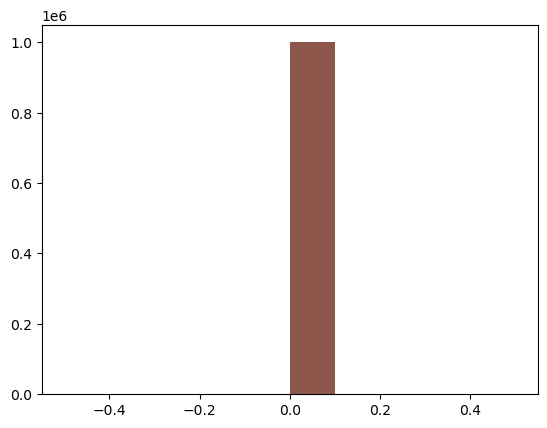

In [ ]:
plt.bar(bin_edges[:-1], stat_hist, width=np.diff(bin_edges), align='edge', color='tab:brown')

In [40]:
len(stat_hist), len(bin_edges)

(10, 11)

In [53]:
p_val

0.0

p-value = 1.0


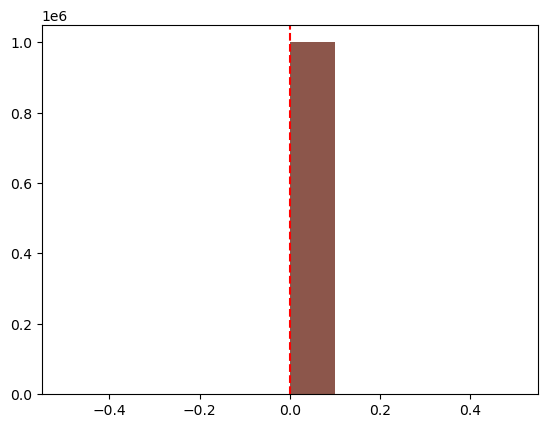

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(stat_dist, color='tab:brown', bins=10)
ax.axvline(x=act_stat, color='red', linestyle='--')
fig.show()
print(f'p-value = {p_val}')